# 환경변수 설정

In [ ]:
# open AI key 등록
import os
OPENAI_API_KEY="본인의 OpenAI API 키를 입력하세요"

# 현재 노트북 커널에 환경변수 등록
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY

# LangSmith API key등록
LANGSMITH_TRACING="true"
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="본인의 LangSmith API 키를 입력하세요"
LANGSMITH_PROJECT="langchain0422"

# 현재 노트북 커널에 환경변수 등록
os.environ['LANGSMITH_TRACING']=LANGSMITH_TRACING
os.environ['LANGSMITH_ENDPOINT']=LANGSMITH_ENDPOINT
os.environ['LANGSMITH_API_KEY']=LANGSMITH_API_KEY
os.environ['LANGSMITH_PROJECT']=LANGSMITH_PROJECT

In [ ]:
!pip install langchain langchain-openai langchain-community faiss-cpu pypdf chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180

## 네이버 뉴스기사를 기반으로 답변하는 챗봇 만들기
- 필요시 크롤링 기술이나 크롤링 에이전트 등을 통해서 뉴스 URL을 수집
- 현재는 직접 URL을 선정하고 챗봇에 삽입하는 방식으로 진행

In [ ]:
# 웹문서 RAG 도구
import bs4 # 웹문서 파싱도구
from langchain_community.document_loaders import WebBaseLoader # 웹문서 로딩 도구
from langchain_text_splitters import RecursiveCharacterTextSplitter # 재귀적 텍스트 분할 도구
from langchain_openai import OpenAIEmbeddings # 임베딩 도구
from langchain_community.vectorstores import FAISS # 벡터데이터베이스 도구

# Chain 구성을 위한 도구
from langchain_core.prompts import ChatPromptTemplate # 프롬프트 템플릿
from langchain.chat_models import init_chat_model # 모델 생성하는 도구
from langchain_core.output_parsers import StrOutputParser # 문자열 파싱 도구
from langchain_core.runnables import RunnablePassthrough # 데이터 전달용 Runnable

### 1. 뉴스기사 파싱하기

In [ ]:
# 파싱할 url
url = "https://n.news.naver.com/article/033/0000050678?cds=news_media_pc&type=editn"

In [ ]:
# 웹 페이지를 읽어주는 로더 생성
web_loader = WebBaseLoader(
    web_path = [url], # 읽을 웹페이지 경로 (여러개 가능)
    bs_kwargs = dict(
        parse_only = bs4.SoupStrainer(
            "div", attrs = {"id" : "newsct_article"}
        )
    )
)

In [ ]:
docs = web_loader.load()
docs

[Document(metadata={'source': 'https://n.news.naver.com/article/033/0000050678?cds=news_media_pc&type=editn'}, page_content='\n\n정치인과 행정가들에 묻습니다…‘범청년행동’ 분노의 반격“지역에서부터 청년 삶 변혁”…지방선거서 ‘답 있다구’ 나서\n\n\n\n‘불평등 물어가는 범청년행동’ 회원들이 지난 4월 15일 서울 중구 서울시청 앞에서 6·3 지방선거 대응 계획 발표 기자회견을 하고 있다. 김창길 기자전남 목포시에서 대학을 졸업한 A씨(29)는 지난해 8월 광주광역시로 이사했다. 부모로부터 재정 지원을 받을 상황이 안 된다는 A씨는 그해 겨울 한 중소기업에 취업했고, 목포에 있을 때(연소득 약 2800만원)보다는 소득이 조금 올랐다. 하지만 A씨는 “저축을 많이 하긴 어렵고, 한 달 벌어 한 달 사는 정도”로 지내고 있다고 했다. 소득에서 9평짜리 원룸 월세 및 관리비로 매달 38만원이 나간다. 여기에 각종 공과금, 통신비, 교통비 등으로 40만원대 고정 지출이 있다. 그 외 생활비와 동생 용돈 등도 써야 한다.A씨의 ‘광주행’은 일자리 때문이었다. A씨는 “목포가 조선소 중심으로 일자리가 있어도 여성인 제가 갈 만한 곳은 별로 없었다”며 “카페 아르바이트나 사무보조 등 여러 가지 일을 하긴 했지만, 일자리가 워낙 없어서 목포 시내에서 무안, 영암까지 생활권이 묶이는데 자차가 없으면 실질적으로 일을 하기 어려웠다”고 했다. 그는 “주변에 보면 광주에서 수도권으로 가는 청년들도 있다. 그런데 제 기준에서는 광주가 전남의 서울 같은 곳이라서, 일자리도 다양하고 대중교통이나 의료시설이나 인프라가 주변 소도시보다는 낫다”고 말했다.이재명 대통령은 지난 4월 17일 공공기관·유관기관 업무 보고를 받는 자리에서 “우리나라 문제 중 심각한 게 청년인데, 수많은 연구조직 중에 청년이 없다는 게 좀 그렇다”며 “다른 나라는 청년부도 만들고, 청년이 장관도 하는데, 우리는 정

### 2. chunk 단위로 쪼개기

In [ ]:
# 구분자는 설정하지 않고 기본값 사용 -> \n\n, \n, " ", ""
news_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100 , # 청크 사이즈
    chunk_overlap = 50 # 청크 오버랩 사이즈
)

news_chunk = news_splitter.split_documents(docs)
len(news_chunk)
# -> 선택한 뉴스 기사에 따라서 chunk 개수 다르다.

# -> 토큰 비용을 덜 고려한다면 chunk_size를 늘리는것이 좋지만, 정보손실이 적어짐
# -> 토큰 비용 부담을 고려 해야 하기 때문에 검색기 생성시 k값의 수를 늘려서 보강

116

### 3.임베딩 후 벡터DB에 저장

In [ ]:
# FAISS 활용
faiss_db = FAISS.from_documents(
    news_chunk, # 청크 데이터
    OpenAIEmbeddings() # 임베딩 도구
)
# -> 116개의 청크데이터를 임베딩 시켜 faiss_db에 넣어준다.

### 4. 검색기 생성

In [ ]:
# chunk 사이즈가 작기 때문에 찾아오는 유사청크 갯수를 늘려서 설정
news_retriver = faiss_db.as_retriever(search_kwagrs={"k":10})

### 5. chain 생성 및 호출

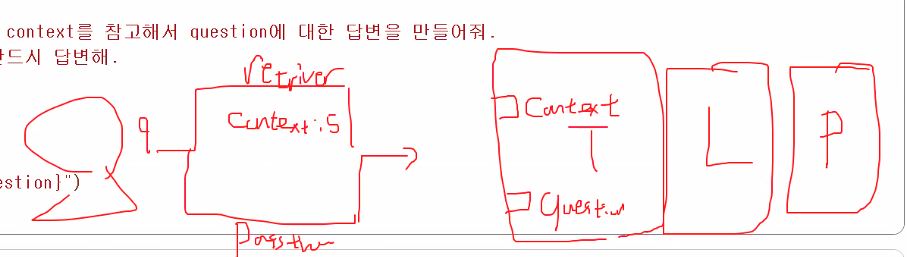

In [ ]:
template = ChatPromptTemplate.from_messages([
    ("system", '''
      너는 뉴스 챗봇이야. 아래 context를 참고해서 question에 대한 답변을 만들어줘.
      모르는 정보는 모른다고 반드시 답변해.

      context : {context}
    '''),
    ("human", "question : {question}")
])

In [ ]:
# chain 구성
news_chain = {"question" : RunnablePassthrough(),
              "context" : news_retriver} | template | init_chat_model("openai:gpt-4o-mini") | StrOutputParser()

In [ ]:
print(news_chain.invoke("청년 정책 문제점에 대해서 알려줘"))

청년 정책의 문제점 중 하나는 청년을 복지 수혜 대상으로만 한정짓는 데 있습니다. 이는 청년단체들이 언급한 바와 같이 청년들의 목소리가 정책 의사결정 과정에 반영되기 어려운 구조를 만들어, 지역 청년 정치인이 나오기 힘든 요인이 되고 있습니다. 또한, 청년들은 노동, 주거, 관계·돌봄 등에서 3대 불평등을 겪고 있으며, 이러한 문제들이 다양한 전환(인구, 디지털, 기후)과 교차하여 청년 정책의 복잡성을 더하고 있습니다. 청년단체들은 이러한 문제를 해결하기 위해 지역별 청년 거점 공간의 필요성을 강조하고 있습니다.


In [ ]:
# news_retriver = faiss_db.as_retriever(search_kwagrs={"k":5}) 일때
news_chain.invoke("청년 정책 문제점에 대해서 알려줘")

'청년 정책의 문제점 중 하나는 청년을 복지 수혜 대상으로만 한정 짓는다는 점입니다. 이로 인해 청년들의 다양한 목소리가 정책 의사결정 과정에 반영되기 어려운 구조가 형성되며, 지역별 청년 거점 공간이 부족하여 돌봄과 관계망을 형성하는 데 어려움이 있습니다. 또한, 청년 정치인이 나오기 힘든 이유도 이러한 관계망의 부족과 관련이 있습니다. 청년단체들은 이러한 문제를 해결하기 위해 지역별 청년 거점 공간의 필요성을 강조하고 있습니다.'

In [ ]:
print(news_chain.invoke("최근 출시된 치킨메뉴 알려줘"))

모른다고 답변하겠습니다. 최근 출시된 치킨 메뉴에 대한 정보는 없습니다.


In [ ]:
# news_retriver = faiss_db.as_retriever(search_kwagrs={"k":10}) 일때
news_chain.invoke("청년 정책 문제점에 대해서 알려줘")

'청년 정책의 문제점 중 하나는 청년을 복지 수혜 대상으로만 한정 짓는 점입니다. 이로 인해 청년 단체들은 청년들이 지역별 거점 공간을 통해 돌봄 및 관계망을 형성하고, 목소리를 모을 수 있는 기회를 제공받지 못하는 상황이 발생하고 있습니다. 또한, 청년들의 목소리가 정책 의사결정 과정에 반영되기 어려운 구조적 문제도 있다는 지적이 있습니다. 이런 문제들로 인해 지역 청년 정치인이 나오기 힘든 상황입니다.'

In [ ]:
# news_retriver = faiss_db.as_retriever(search_kwagrs={"k":10}) 일때
news_chain.invoke("청년 정책에서 일자리 문제에 대해서 알려줘")

"청년 정책에서 일자리 문제는 현재 심각한 상황에 놓여 있으며, 특히 여성 청년들이 배제되는 문제도 지적되고 있습니다. 일자리 창출 방식에서 변화가 필요하다는 목소리가 있으며, 심각한 청년 일자리 진입 문제와 노동권 측면에서도 청년들이 열악한 위치에 처해 있다는 분석이 있습니다. \n\n지자체들은 지역 청년 일자리 문제를 '특구' 지정이나 대기업 유치 같은 방법으로 해결하려고 하지만, 이러한 방식은 실효성이 입증되지 않았습니다. 이러한 상황에서 청년들은 지역에서 겪는 문제를 정책적으로 해소해달라는 요구가 커지고 있습니다. \n\n추가로, 구체적인 정책이나 해결 방안은 문서에서 다루어지지 않아 알 수 없습니다."